# 49 · lab correction with control genes (RUVg) · autoimmune diseases against healthy children

Reads the raw counts of notebooks 40 (internal), 12 (SLE, GSE232381) and 45 (healthy children, GSE69529), and the
negative control genes of notebook 48. Writes figures to
`figures/CANDLE_SAVI/` and `ruv_diagnostics.csv` in `data/run_artifacts/CANDLE_SAVI/`.

**Objective.** Remove the lab difference from the comparison of the diseases with healthy children, using genes
that are known not to change with SLE.

**Why this is possible here.** ComBat-seq needs samples of the same kind in both batches; here each lab holds
one kind of sample. RUVg (remove unwanted variation with control genes; Risso D, Ngai J, Speed TP, Dudoit S.
*Nat Biotechnol* 2014;32:896-902; Gagnon-Bartsch JA, Speed TP. *Biostatistics* 2012;13:539-552) needs instead a
set of negative control genes: genes that do not change with the biology compared. Their differences between
samples are taken as unwanted variation; RUVg finds the main patterns of that variation (k factors, one value
per sample each), and the factors enter the model as extra terms.

**Control genes.** The negative control genes of notebook 48: no difference between SLE and healthy children within
the same lab, in GSE65391 and in GSE135779.

**Limits.** The correction is only as good as the control genes: it assumes the lab difference shows in genes that
do not change with disease. The negative controls come from SLE studies; a gene unchanged in SLE may change in
CANDLE, SAVI, AGS or UAID.

**What this notebook shows.** For k = 1, 2, 3 factors, against the uncorrected model (k = 0):
PCA and relative log expression by source; the number of genes different from healthy; the interferon genes
(positive controls), the NF-kB-only controls, and the hemoglobin genes (a processing difference); and, for SLE,
agreement with the same-lab results of notebook 48. The choice of k is Anne's; the final results
follow in a later step.

## The pooled counts, as in notebook 46

In [1]:
source("../src/paths.R")
suppressMessages({library(limma); library(edgeR); library(RUVSeq)})
x   <- readRDS(art("CANDLE_SAVI", "counts_raw.rds")); s <- readRDS(art("CANDLE_SAVI", "samples.rds"))
hc  <- readRDS(art("CANDLE_SAVI", "healthy_counts.rds")); hs <- readRDS(art("CANDLE_SAVI", "healthy_samples.rds"))
sle <- readRDS(art("GSE232381", "expression.rds"))
gi  <- read.delim(file.path(NCBI, "Homo_sapiens.gene_info.gz"), quote = "", colClasses = "character")
n_ens <- lengths(regmatches(gi$dbXrefs, gregexpr("Ensembl:ENSG", gi$dbXrefs)))
ens <- ifelse(n_ens == 1, sub(".*Ensembl:(ENSG[0-9]+).*", "\\1", gi$dbXrefs), NA)
se  <- ens[match(rownames(sle$all_counts), gi$Symbol)]
sle_counts <- rowsum(round(sle$all_counts[!is.na(se), ]), se[!is.na(se)])
genes <- Reduce(intersect, list(rownames(x$counts), rownames(hc), rownames(sle_counts)))
meta <- rbind(
  data.frame(sample = s$sample, patient = s$patient, group = s$diagnosis, batch = s$batch, source = s$Sequencing_Facility),
  data.frame(sample = colnames(sle_counts), patient = colnames(sle_counts), group = "SLE", batch = "GSE232381", source = "GSE232381"),
  data.frame(sample = hs$sample, patient = hs$sample, group = hs$block, batch = paste0("GSE69529-", hs$set), source = "GSE69529"))
counts <- cbind(x$counts[genes, s$sample], sle_counts[genes, ], hc[genes, hs$sample])
meta$group <- factor(meta$group, levels = c("AGS", "CANDLE", "SAVI", "UAID", "SLE", "healthy_under2", "healthy_2plus"))
meta$batch_term <- relevel(factor(make.names(ifelse(meta$batch %in% c("BMC-HGSC", "GSE232381", "GSE69529-set1"), "reference", meta$batch))), ref = "reference")
keep <- filterByExpr(DGEList(counts), group = meta$group); counts <- counts[keep, ]
c(genes = nrow(counts), samples = ncol(counts))

genes samples 
  14487     228

**Explanation**
- The same pooled data as notebook 46: the internal raw counts, the GSE232381 SLE counts (named by Ensembl
  identifier through NCBI gene_info, rounded), and the healthy children; the genes common to the three; the
  same groups and batch terms; the same `filterByExpr` filter.

**Result.** 14,487 genes x 228 samples (160 internal, 25 SLE, 43 healthy children).

## The control gene sets

In [2]:
neg <- read.csv(art("CANDLE_SAVI", "control_genes_negative.csv"))$gene_id
sets <- list(same_lab_negative = intersect(neg, rownames(counts)))
sapply(sets, length)

same_lab_negative 
              777

**Explanation**
- `neg` holds the negative control genes of notebook 48; `sets` keeps those among the genes of the pooled data.
- The line counts them.

**Result.** All 777 negative control genes are among the genes of the pooled data.

## RUVg: the factors of unwanted variation

In [3]:
uq <- betweenLaneNormalization(counts, which = "upper")
W  <- list()
for (nm in names(sets)) for (k in 1:3) W[[paste0(nm, "_k", k)]] <- RUVg(uq, sets[[nm]], k = k)$W
sapply(W, ncol)

same_lab_negative_k1 same_lab_negative_k2 same_lab_negative_k3 
                   1                    2                    3

**Explanation**
- `betweenLaneNormalization(counts, which = "upper")` scales each sample by its upper quartile of counts, the
  normalization the RUVSeq authors use before RUVg (Risso et al. 2014).
- `RUVg(uq, controls, k)` finds, from the control genes only, the k main patterns of variation across the samples;
  `$W` holds them, one column per factor, one value per sample.
- `W` keeps the factors for each control set and k = 1, 2, 3.

**Result.** Factors estimated for k = 1, 2 and 3.

## PCA and relative log expression, before and after

,k0,same_lab_negative_k1,same_lab_negative_k2,same_lab_negative_k3
RLE_median_IQR,1.044,0.878,0.839,0.763
PC1_R2_by_source,0.947,0.967,0.961,0.991


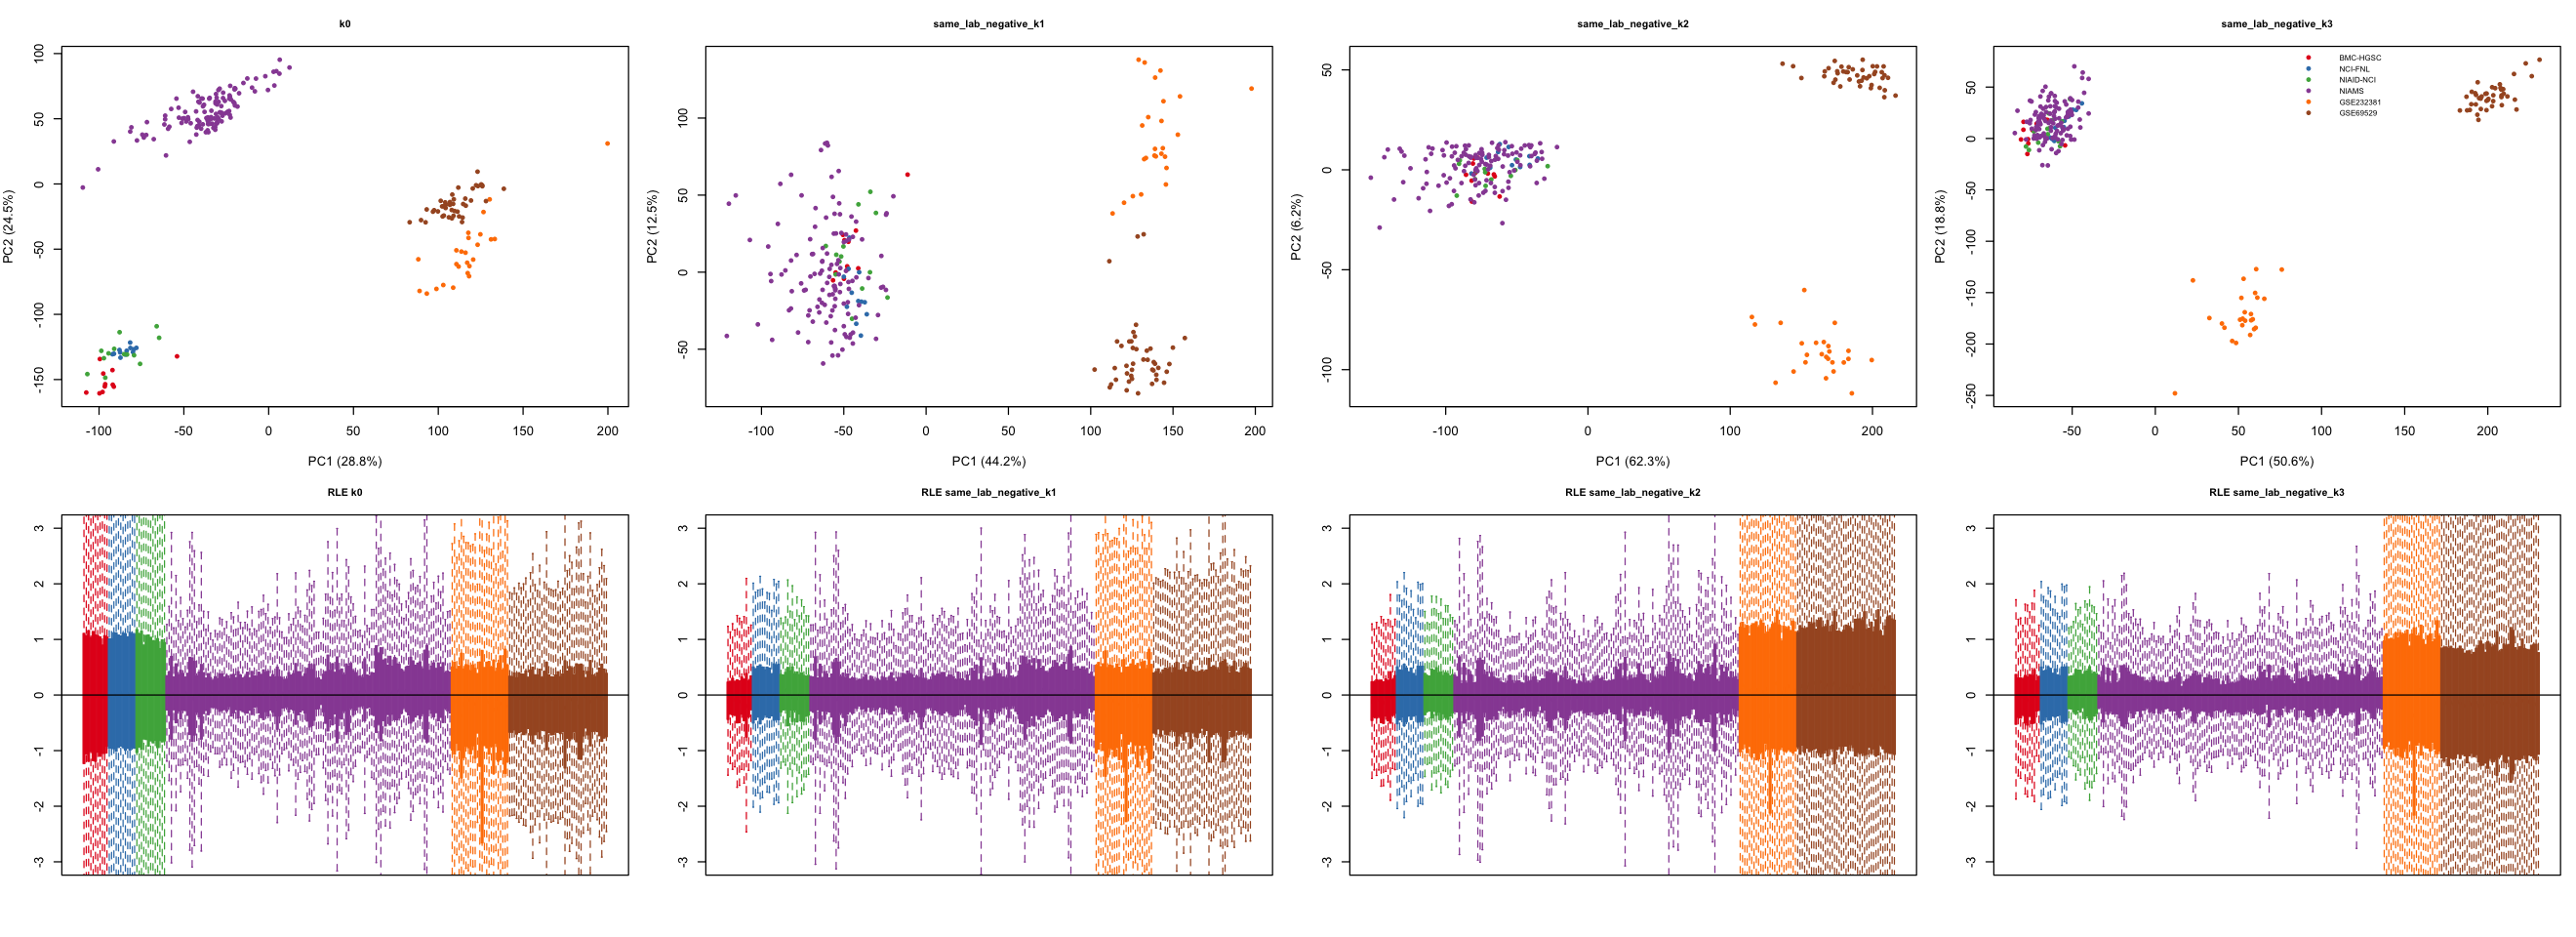

In [4]:
src_col <- c("BMC-HGSC" = "#E41A1C", "NCI-FNL" = "#377EB8", "NIAID-NCI" = "#4DAF4A", NIAMS = "#984EA3", GSE232381 = "#FF7F00", GSE69529 = "#A65628")
lcpm <- cpm(calcNormFactors(DGEList(counts)), log = TRUE)
resid_after <- function(w) {                                   # log-CPM with the W factors removed, groups kept
  removeBatchEffect(lcpm, covariates = w, design = model.matrix(~ 0 + group, meta))
}
panels <- c(list(k0 = lcpm), lapply(W, resid_after))
rle_spread <- sapply(panels, function(M) { r <- M - apply(M, 1, median); median(apply(r, 2, IQR)) })
pca_sep <- sapply(panels, function(M) { p <- prcomp(t(M))$x[, 1:2]
  summary(lm(p ~ meta$source))$`Response PC1`$r.squared })
round(rbind(RLE_median_IQR = rle_spread, PC1_R2_by_source = pca_sep), 3)
figure <- function() {
  sel <- c("k0", grep("_k", names(panels), value = TRUE))
  par(mfrow = c(2, length(sel)), mar = c(4, 4, 3, 1))
  for (nm in sel) { p <- prcomp(t(panels[[nm]])); v <- round(100 * p$sdev[1:2]^2 / sum(p$sdev^2), 1)
    plot(p$x[, 1:2], col = src_col[meta$source], pch = 19, cex = 0.6, main = nm, cex.main = 0.8,
         xlab = sprintf("PC1 (%s%%)", v[1]), ylab = sprintf("PC2 (%s%%)", v[2])) }
  legend("topright", legend = names(src_col), col = src_col, pch = 19, cex = 0.6, bty = "n")
  for (nm in sel) { r <- panels[[nm]] - apply(panels[[nm]], 1, median)
    boxplot(r, col = src_col[meta$source], border = src_col[meta$source], outline = FALSE, xaxt = "n", ylim = c(-3, 3),
            main = paste("RLE", nm), cex.main = 0.8); abline(h = 0) }
}
options(repr.plot.width = 22, repr.plot.height = 8)
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("CANDLE_SAVI", "49_pca_rle.png"), width = 22, height = 8, units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `lcpm` holds log2 counts per million after TMM normalization.
- `resid_after(w)` removes the W factors from the log-CPM values while keeping the group means
  (`removeBatchEffect()`, limma), for display only; the tests below put W into the model instead.
- Relative log expression (RLE; Gandolfo LC, Speed TP. RLE plots: visualizing unwanted variation in
  high-dimensional data. *PLoS One* 2018;13:e0191629): each gene's value minus its median over samples. With
  little unwanted variation, every sample's box is centred at 0 and narrow. `RLE_median_IQR` is the median width
  (interquartile range) of the samples' boxes.
- `PC1_R2_by_source` is the share of PC1 explained by the source (the four internal facilities, GSE232381,
  GSE69529): near 1 means PC1 is the lab.
- The figure shows, for k = 0 and each control set and k, the samples on PC1 and PC2 coloured by source (top) and
  the RLE boxes coloured by source (bottom).

**Result.** The width of the RLE boxes shrinks with each factor (median interquartile range 1.04 without correction;
0.88, 0.84 and 0.76 with k = 1, 2, 3). PC1 stays explained by the source (share 0.95 without correction, 0.96 to
0.99 with correction). Because each lab holds one kind of sample, the group means kept in the display are also
the lab means, so this measure cannot show the lab difference falling.

## The comparisons against healthy, for each control set and k

In [5]:
dz  <- c("AGS", "CANDLE", "SAVI", "UAID", "SLE")
same_lab <- read.csv(art("CANDLE_SAVI", "sle_vs_healthy_same_lab.csv"))
irg <- read_gene_set("ifn-response-genes-28.txt"); nfk <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
hb  <- c("HBA1", "HBA2", "HBB", "HBD", "HBG1", "HBG2", "HBZ")
name_of <- x$genes[rownames(counts), "gene_name"]
run_model <- function(w) {
  d <- if (is.null(w)) model.matrix(~ 0 + group + batch_term, meta) else model.matrix(~ 0 + group + batch_term + w, meta)
  colnames(d) <- sub("^group", "", colnames(d))
  y <- calcNormFactors(DGEList(counts)); v <- voom(y, d)
  cr <- duplicateCorrelation(v, d, block = meta$patient)$consensus
  fit <- lmFit(v, d, block = meta$patient, correlation = cr)
  cm <- makeContrasts(contrasts = c(paste0(dz, " - healthy_2plus"), paste0("(", paste(dz, collapse = " + "), ")/5 - healthy_2plus")), levels = d)
  colnames(cm) <- c(dz, "block"); eBayes(contrasts.fit(fit, cm))
}
fits <- c(list(k0 = run_model(NULL)), lapply(W, run_model))
diag <- do.call(rbind, lapply(names(fits), function(nm) { f <- fits[[nm]]
  lf <- f$coefficients; ap <- apply(f$p.value, 2, p.adjust, method = "BH")
  sl <- same_lab[match(rownames(lf), same_lab$gene_id), ]
  conf <- !is.na(sl$confirmed_SLE) & sl$confirmed_SLE != ""
  data.frame(model = nm,
    block_genes_adjp_0.05 = sum(ap[, "block"] < 0.05),
    IRG_median_log2FC_CANDLE = median(lf[name_of %in% irg, "CANDLE"]), IRG_median_log2FC_SLE = median(lf[name_of %in% irg, "SLE"]),
    IRG_median_log2FC_AGS = median(lf[name_of %in% irg, "AGS"]),
    NFkB_median_log2FC_block = median(lf[name_of %in% nfk, "block"]),
    hemoglobin_median_log2FC_SLE = median(lf[name_of %in% hb, "SLE"]),
    SLE_spearman_with_GSE65391 = cor(lf[!is.na(sl$logFC_GSE65391), "SLE"], sl$logFC_GSE65391[!is.na(sl$logFC_GSE65391)], method = "spearman"),
    SLE_sign_agreement_confirmed = mean(sign(lf[conf, "SLE"]) == ifelse(sl$confirmed_SLE[conf] == "up", 1, -1)))
}))
write.csv(diag, art("CANDLE_SAVI", "ruv_diagnostics.csv"), row.names = FALSE)
format(diag, digits = 2)

,model,block_genes_adjp_0.05,IRG_median_log2FC_CANDLE,IRG_median_log2FC_SLE,IRG_median_log2FC_AGS,NFkB_median_log2FC_block,hemoglobin_median_log2FC_SLE,SLE_spearman_with_GSE65391,SLE_sign_agreement_confirmed
,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>
1,k0,11440,1.63,2.07,0.48,-0.191,10.3,0.26,0.791
2,same_lab_negative_k1,7818,0.46,2.02,-0.67,-0.551,10.5,0.25,0.773
3,same_lab_negative_k2,8741,1.21,0.15,0.57,-0.095,8.6,-0.40,0.227
4,same_lab_negative_k3,8235,0.01,-1.08,-0.85,-1.180,2.9,-0.61,0.087


**Explanation**
- `run_model(w)` fits the model of notebook 46 against healthy children aged 2 or older, with the W factors as
  extra terms (`+ w`); without `w` it is the uncorrected model (k = 0). The patient is a block, estimated once per
  model. The comparisons are each disease and the five-disease block against healthy.
- For each model the table gives:
  - `block_genes_adjp_0.05`: genes different between the five-disease block and healthy (adjusted p < 0.05);
  - the median log2 fold change of the 28 interferon response genes in CANDLE, SLE and AGS (positive controls:
    should stay up in CANDLE and SLE);
  - the median log2 fold change of the 11 NF-kB-only controls in the block (should stay near 0);
  - the median log2 fold change of the hemoglobin genes in SLE (a processing difference: should shrink);
  - for SLE, the Spearman correlation of its log2 fold changes with the same-lab GSE65391 results, and the share of
    the confirmed SLE genes of notebook 48 that change in the confirmed direction (both should rise if the lab
    difference is removed).
- `ruv_diagnostics.csv` keeps the table.

**Result.**

| model | genes different, block against healthy | interferon genes, median log2 fold change: CANDLE / SLE / AGS | NF-kB controls, block | hemoglobin genes, SLE | SLE against same-lab results: Spearman / confirmed genes in the confirmed direction |
|---|---|---|---|---|---|
| k = 0 (no correction) | 11,440 | 1.63 / 2.07 / 0.48 | -0.19 | 10.3 | 0.26 / 79% |
| k = 1 | 7,818 | 0.46 / 2.02 / -0.67 | -0.55 | 10.5 | 0.25 / 77% |
| k = 2 | 8,741 | 1.21 / 0.15 / 0.57 | -0.10 | 8.6 | -0.40 / 23% |
| k = 3 | 8,235 | 0.01 / -1.08 / -0.85 | -1.18 | 2.9 | -0.61 / 9% |

No k passes the checks. k = 1 lowers the interferon genes in CANDLE (1.63 to 0.46) and AGS while the hemoglobin
genes in SLE stay as high as without correction. k = 2 removes the interferon genes in SLE (2.07 to 0.15) and turns
the agreement of SLE with the same-lab results negative. k = 3 removes the interferon signal from every disease.
The factors estimated from the control genes follow the groups, because each lab holds one kind of sample, so
removing them removes disease signal along with the lab difference. With these control genes, RUVg does not
separate the lab difference from disease in these data; the uncorrected model (k = 0) keeps the positive controls
and agrees best with the same-lab SLE results.

## References

1. Risso D, Ngai J, Speed TP, Dudoit S. Normalization of RNA-seq data using factor analysis of control genes or samples. *Nat Biotechnol* 2014;32:896-902.
2. Gagnon-Bartsch JA, Speed TP. Using control genes to correct for unwanted variation in microarray data. *Biostatistics* 2012;13:539-552.
3. Gandolfo LC, Speed TP. RLE plots: visualizing unwanted variation in high-dimensional data. *PLoS One* 2018;13:e0191629.
4. Law CW, Chen Y, Shi W, Smyth GK. voom: precision weights unlock linear model analysis tools for RNA-seq read counts. *Genome Biol* 2014;15:R29.
5. Ritchie ME, Phipson B, Wu D, Hu Y, Law CW, Shi W, Smyth GK. limma powers differential expression analyses for RNA-sequencing and microarray studies. *Nucleic Acids Res* 2015;43:e47.
6. Smyth GK, Michaud J, Scott HS. Use of within-array replicate spots for assessing differential expression in microarray experiments. *Bioinformatics* 2005;21:2067-2075.
7. Robinson MD, Oshlack A. A scaling normalization method for differential expression analysis of RNA-seq data. *Genome Biol* 2010;11:R25.
8. Chen Y, Lun ATL, Smyth GK. From reads to genes to pathways: differential expression analysis of RNA-Seq experiments using Rsubread and the edgeR quasi-likelihood pipeline. *F1000Research* 2016;5:1438.
9. Brown GR, Hem V, Katz KS, et al. Gene: a gene-centered information resource at NCBI. *Nucleic Acids Res* 2015;43:D36-D42.
10. Jolliffe IT. *Principal Component Analysis*, 2nd ed. Springer, New York 2002.